In [3]:
# <<<./ Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,ModelCheckpoint,TensorBoard)
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import preprocess_input
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
import os
import mlflow

In [2]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [5]:
# <<<./ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Base Path
PATH = '/content/drive/MyDrive/final-project/dataset/data/raw/skin2/dataset/'

## Preprocess for DL

In [8]:
# <<<./ Batch Size and Image Size
batch_size = 32
img_size = (380, 380)

# <<<./ Train Dataset
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    seed=42)

# <<<./ Validation Dataset
valid_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'valid'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    seed=42)

# <<<./ Test Dataset
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'test'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    seed=42)

# <<<./ Classes Detail
class_names = train_ds.class_names
n_classes = len(class_names)

print(f'Number of Classes  : {n_classes}')
print(f'Classes Sample     : {class_names}')
print(f'Train Batches      : {len(train_ds)}')
print(f'Validation Batches : {len(valid_ds)}')
print(f'Test Batches       : {len(test_ds)}')

Found 3174 files belonging to 8 classes.
Found 537 files belonging to 8 classes.
Found 522 files belonging to 8 classes.
Number of Classes  : 8
Classes Sample     : ['dark spots', 'inflammatory acne', 'non inflammatory acne black heads', 'non inflammatory acne white heads', 'pigmentation', 'pores', 'redness', 'wrinkles']
Train Batches      : 100
Validation Batches : 17
Test Batches       : 17


In [9]:
# <<<./ Preprocessing
def preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

# <<<./ Augment
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)], name='data_augmentation')

# <<<./ Apply Core Pipeline
train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)

## Modeling

In [8]:
# <<<./ EfficientNetB4
def transfer_model(n_outputs, img_size=img_size):
    base_model = EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=None,
        input_shape=(*img_size, 3))
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(*img_size, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='swish')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_outputs, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='EfficientNetB4_FocalLoss_Isolated')
    return model

In [9]:
# <<<./ Compile Model
model = transfer_model(n_outputs=8)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0),
    metrics=['accuracy'])

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [10]:
# Log Callbacks
log_dir = os.path.join('logs', datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=2),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=2),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=2),
    TensorBoard(log_dir=log_dir)]

In [11]:
# <<<./ MLFlow Tracking Google Drive
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:///content/drive/MyDrive/final-project/mlruns')
mlflow.set_experiment('skinanalysis2')

<Experiment: artifact_location='file:///content/drive/MyDrive/final-project/mlruns/946114055142948413', creation_time=1782806025086, effective_trace_archival_retention=None, experiment_id='946114055142948413', last_update_time=1782806025086, lifecycle_stage='active', name='skinanalysis2', tags={}, trace_location=None, workspace='default'>

In [ ]:
# Reload MLFlow Artifacts (Iteratively After Each Run)
# run_id = 'a120d8dca0f94556aaa716b569662594'

local_path = mlflow.artifacts.download_artifacts(
    run_id=run_id,
    artifact_path='best_model.keras')

model = tf.keras.models.load_model(
    local_path,
    custom_objects={'loss_fn': categorical_focal_loss(gamma=1.5)})

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=categorical_focal_loss(gamma=1.5),
    metrics=['accuracy'])

In [12]:
# <<<./ MLFlow Logging
with mlflow.start_run(run_name='logged_attempt1A'):
    mlflow.log_params({
        'backbone': 'EfficientNetB4',
        'dense_units': 256,
        'gamma': 2,
        'dropout': 0.5,
        'learning_rate': 1e-4,
    })

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=30,
        callbacks=callbacks)

    # Log Metric
    for epoch, (acc, loss, val_acc, val_loss) in enumerate(zip(
        history.history['accuracy'],
        history.history['loss'],
        history.history['val_accuracy'],
        history.history['val_loss'])):

        mlflow.log_metrics({
            'accuracy': acc,
            'loss': loss,
            'val_accuracy': val_acc,
            'val_loss': val_loss
        }, step=epoch)

    mlflow.log_artifact('/content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras')

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3081 - loss: 0.3309
Epoch 1: val_loss improved from None to 0.19317, saving model to /content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras

Epoch 1: finished saving model to /content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 458s 4s/step - accuracy: 0.4379 - loss: 0.2733 - val_accuracy: 0.6778 - val_loss: 0.1932 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6110 - loss: 0.1810
Epoch 2: val_loss improved from 0.19317 to 0.14466, saving model to /content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras

Epoch 2: finished saving model to /content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6396 - loss: 0.1682 - val_accuracy: 0.7263 - val_loss: 0.1447 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/s

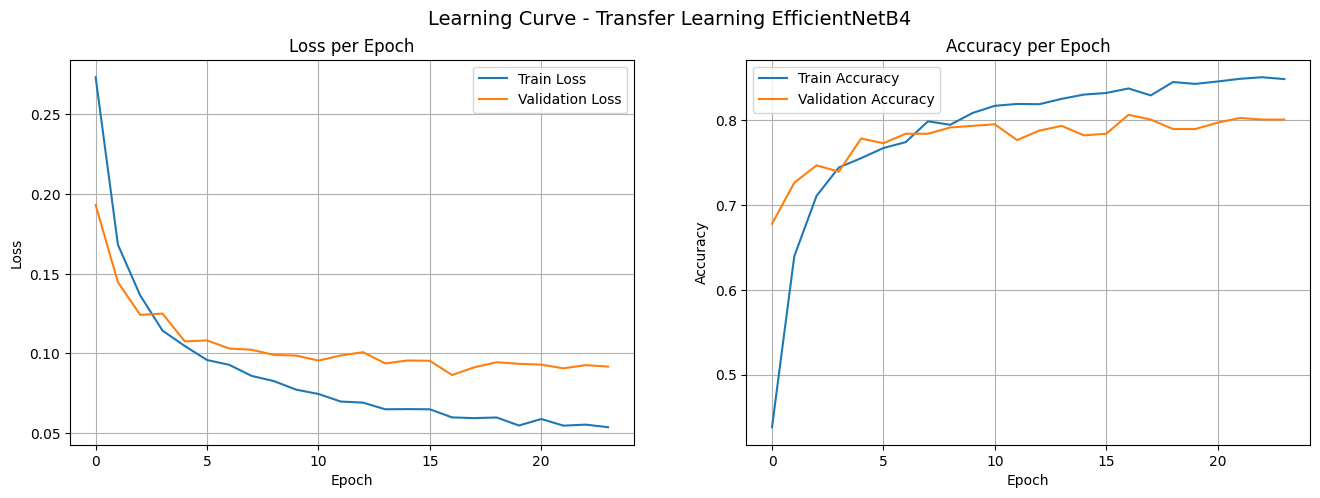

In [13]:
# Learning Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Show
plt.suptitle('Learning Curve - Transfer Learning EfficientNetB4', fontsize=14)
plt.show()

In [14]:
# Collect Predictions
y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    y_true.append(np.argmax(labels.numpy(), axis=1))
    y_pred.append(np.argmax(predictions, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

Classification Report

                                   precision    recall  f1-score   support

                       dark spots       0.62      0.32      0.42        79
                inflammatory acne       0.64      0.87      0.74        78
non inflammatory acne black heads       0.77      0.57      0.66        40
non inflammatory acne white heads       0.75      0.75      0.75        40
                     pigmentation       0.94      0.89      0.92        75
                            pores       0.83      0.99      0.90        75
                          redness       0.85      1.00      0.92        75
                         wrinkles       0.99      0.95      0.97        75

                         accuracy                           0.81       537
                        macro avg       0.80      0.79      0.78       537
                     weighted avg       0.80      0.81      0.79       537



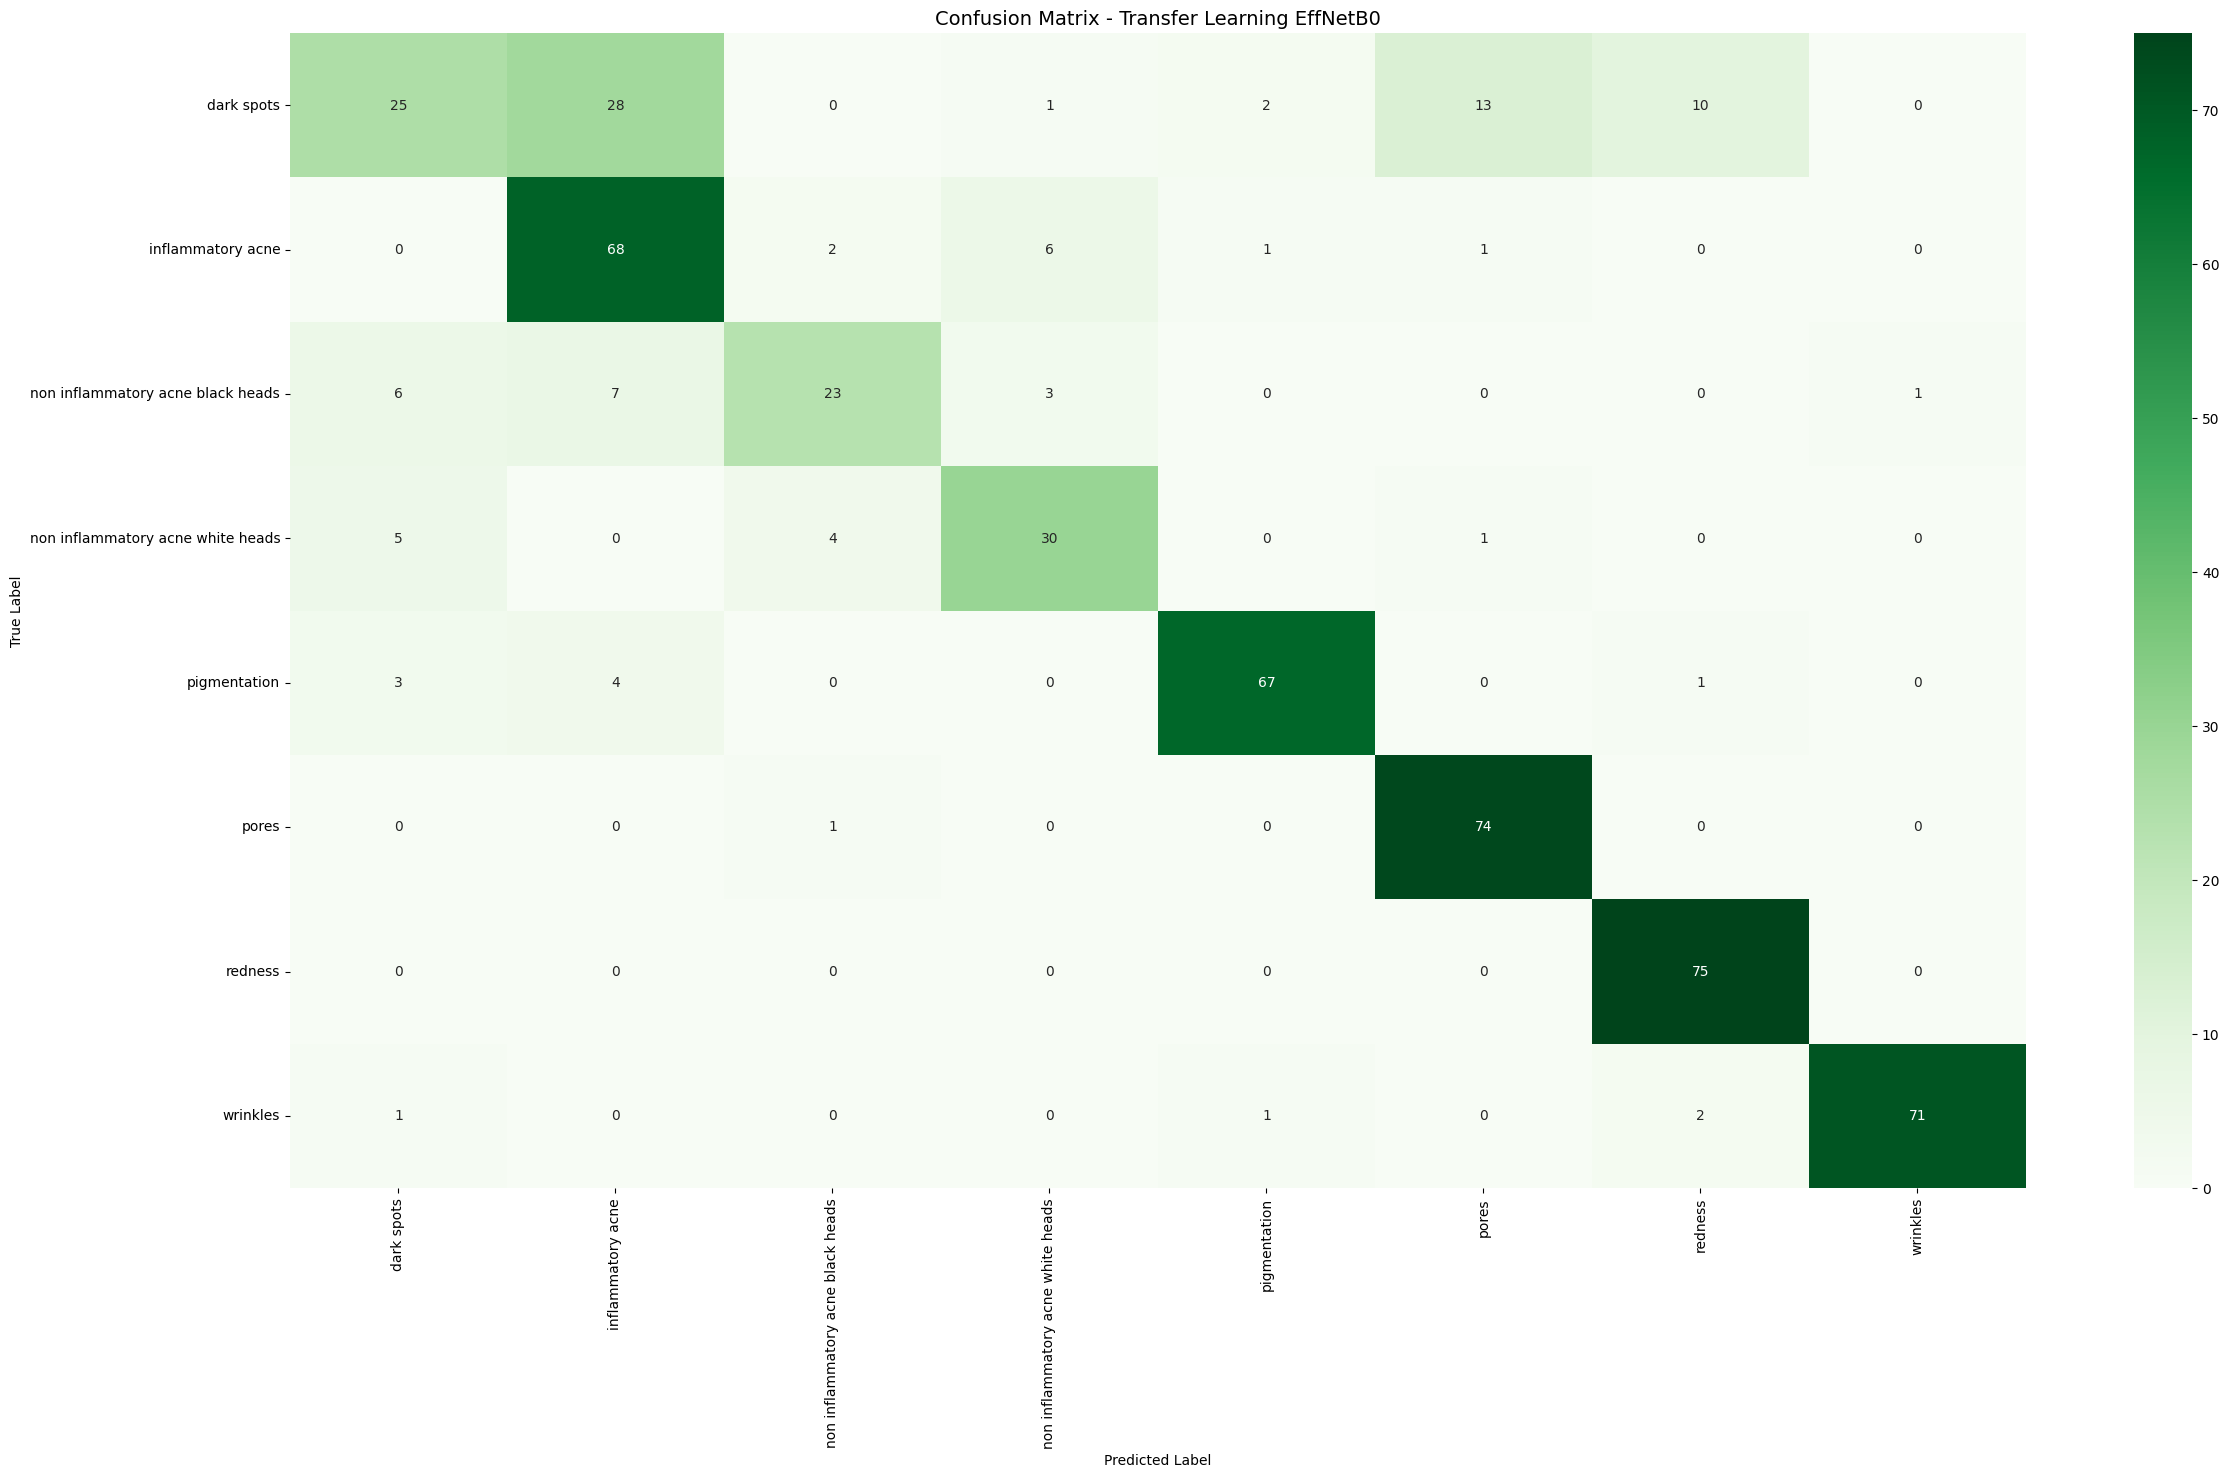

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.8063 - loss: 0.0864
Validation Loss : 0.086

Validation Accuracy : 0.806


In [15]:
# Classification Report
print('Classification Report\n')
print(classification_report(
    y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(28, 15))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Transfer Learning EffNetB0', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Overall Metrics
val_loss, val_accuracy = model.evaluate(valid_ds, verbose=1)
print(f'Validation Loss : {val_loss:.3f}')
print(f'\nValidation Accuracy : {val_accuracy:.3f}')

In [10]:
# Load Best Model and Unfreeze Layers
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras')

backbone = model.layers[1]
backbone.trainable = True

# Unfreeze Last 40 Layers
for layer in backbone.layers[:-20]:
    layer.trainable = False

for layer in backbone.layers[-20:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = [layer for layer in backbone.layers if layer.trainable]

print(f'Unfrozen Layers: {len(trainable_layers)}')

# Recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2),
    metrics=['accuracy'])

# Log Callbacks
log_dir_tuned = os.path.join('logs', 'finetune_' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_tuned = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/final-project/attempt1A/best_model.finetuned.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1),
    TensorBoard(log_dir=log_dir_tuned)]

# Fit Fine-tuned Train
history_tuned = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=callbacks_tuned)

Unfrozen Layers: 15
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8234 - loss: 0.0615
Epoch 1: val_loss improved from None to 0.08987, saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.finetuned.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.8308 - loss: 0.0589 - val_accuracy: 0.7970 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8406 - loss: 0.0562
Epoch 2: val_loss did not improve from 0.08987
100/100 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8488 - loss: 0.0545 - val_accuracy: 0.7989 - val_loss: 0.0929 - learning_rate: 1.0000e-05
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8404 - loss: 0.0560
Epoch 3: val_loss did not improve from 0.08987
100/100 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8384 - loss: 0.0554 - val_accuracy:

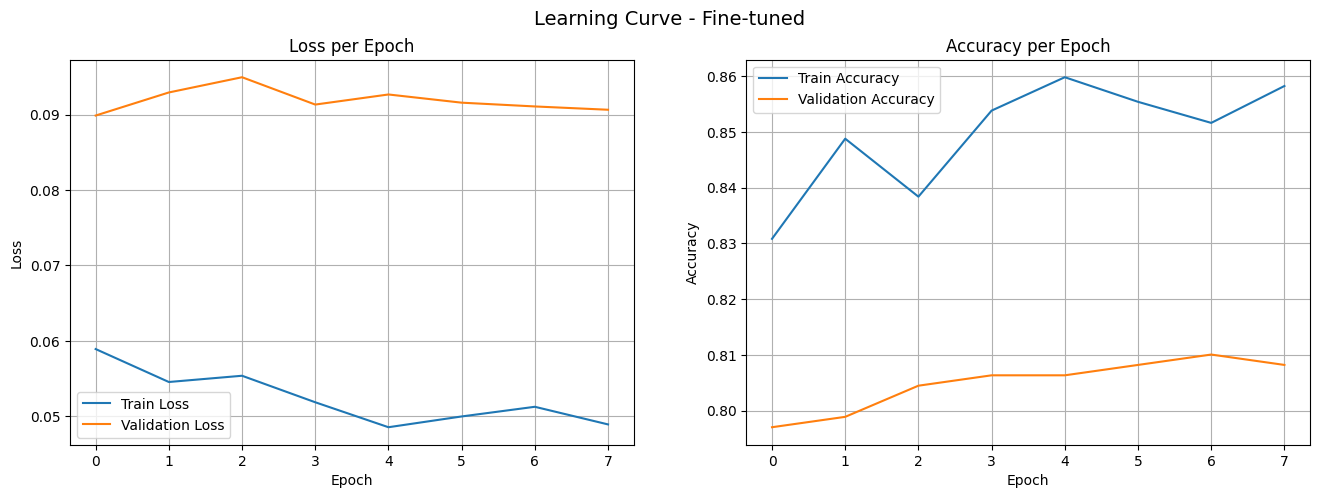

In [11]:
# Learning Curve Fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_tuned.history['loss'], label='Train Loss')
axes[0].plot(history_tuned.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_tuned.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Show
plt.suptitle('Learning Curve - Fine-tuned', fontsize=14)
plt.show()

In [12]:
# Collect Predictions
y_true_tuned = []
y_pred_tuned = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    y_true_tuned.append(np.argmax(labels.numpy(), axis=1))
    y_pred_tuned.append(np.argmax(predictions, axis=1))

y_true_tuned = np.concatenate(y_true_tuned)
y_pred_tuned = np.concatenate(y_pred_tuned)

Classification Report

                                   precision    recall  f1-score   support

                       dark spots       0.59      0.28      0.38        79
                inflammatory acne       0.63      0.87      0.73        78
non inflammatory acne black heads       0.76      0.55      0.64        40
non inflammatory acne white heads       0.73      0.75      0.74        40
                     pigmentation       0.96      0.88      0.92        75
                            pores       0.80      0.99      0.88        75
                          redness       0.85      1.00      0.92        75
                         wrinkles       0.99      0.95      0.97        75

                         accuracy                           0.80       537
                        macro avg       0.79      0.78      0.77       537
                     weighted avg       0.79      0.80      0.78       537



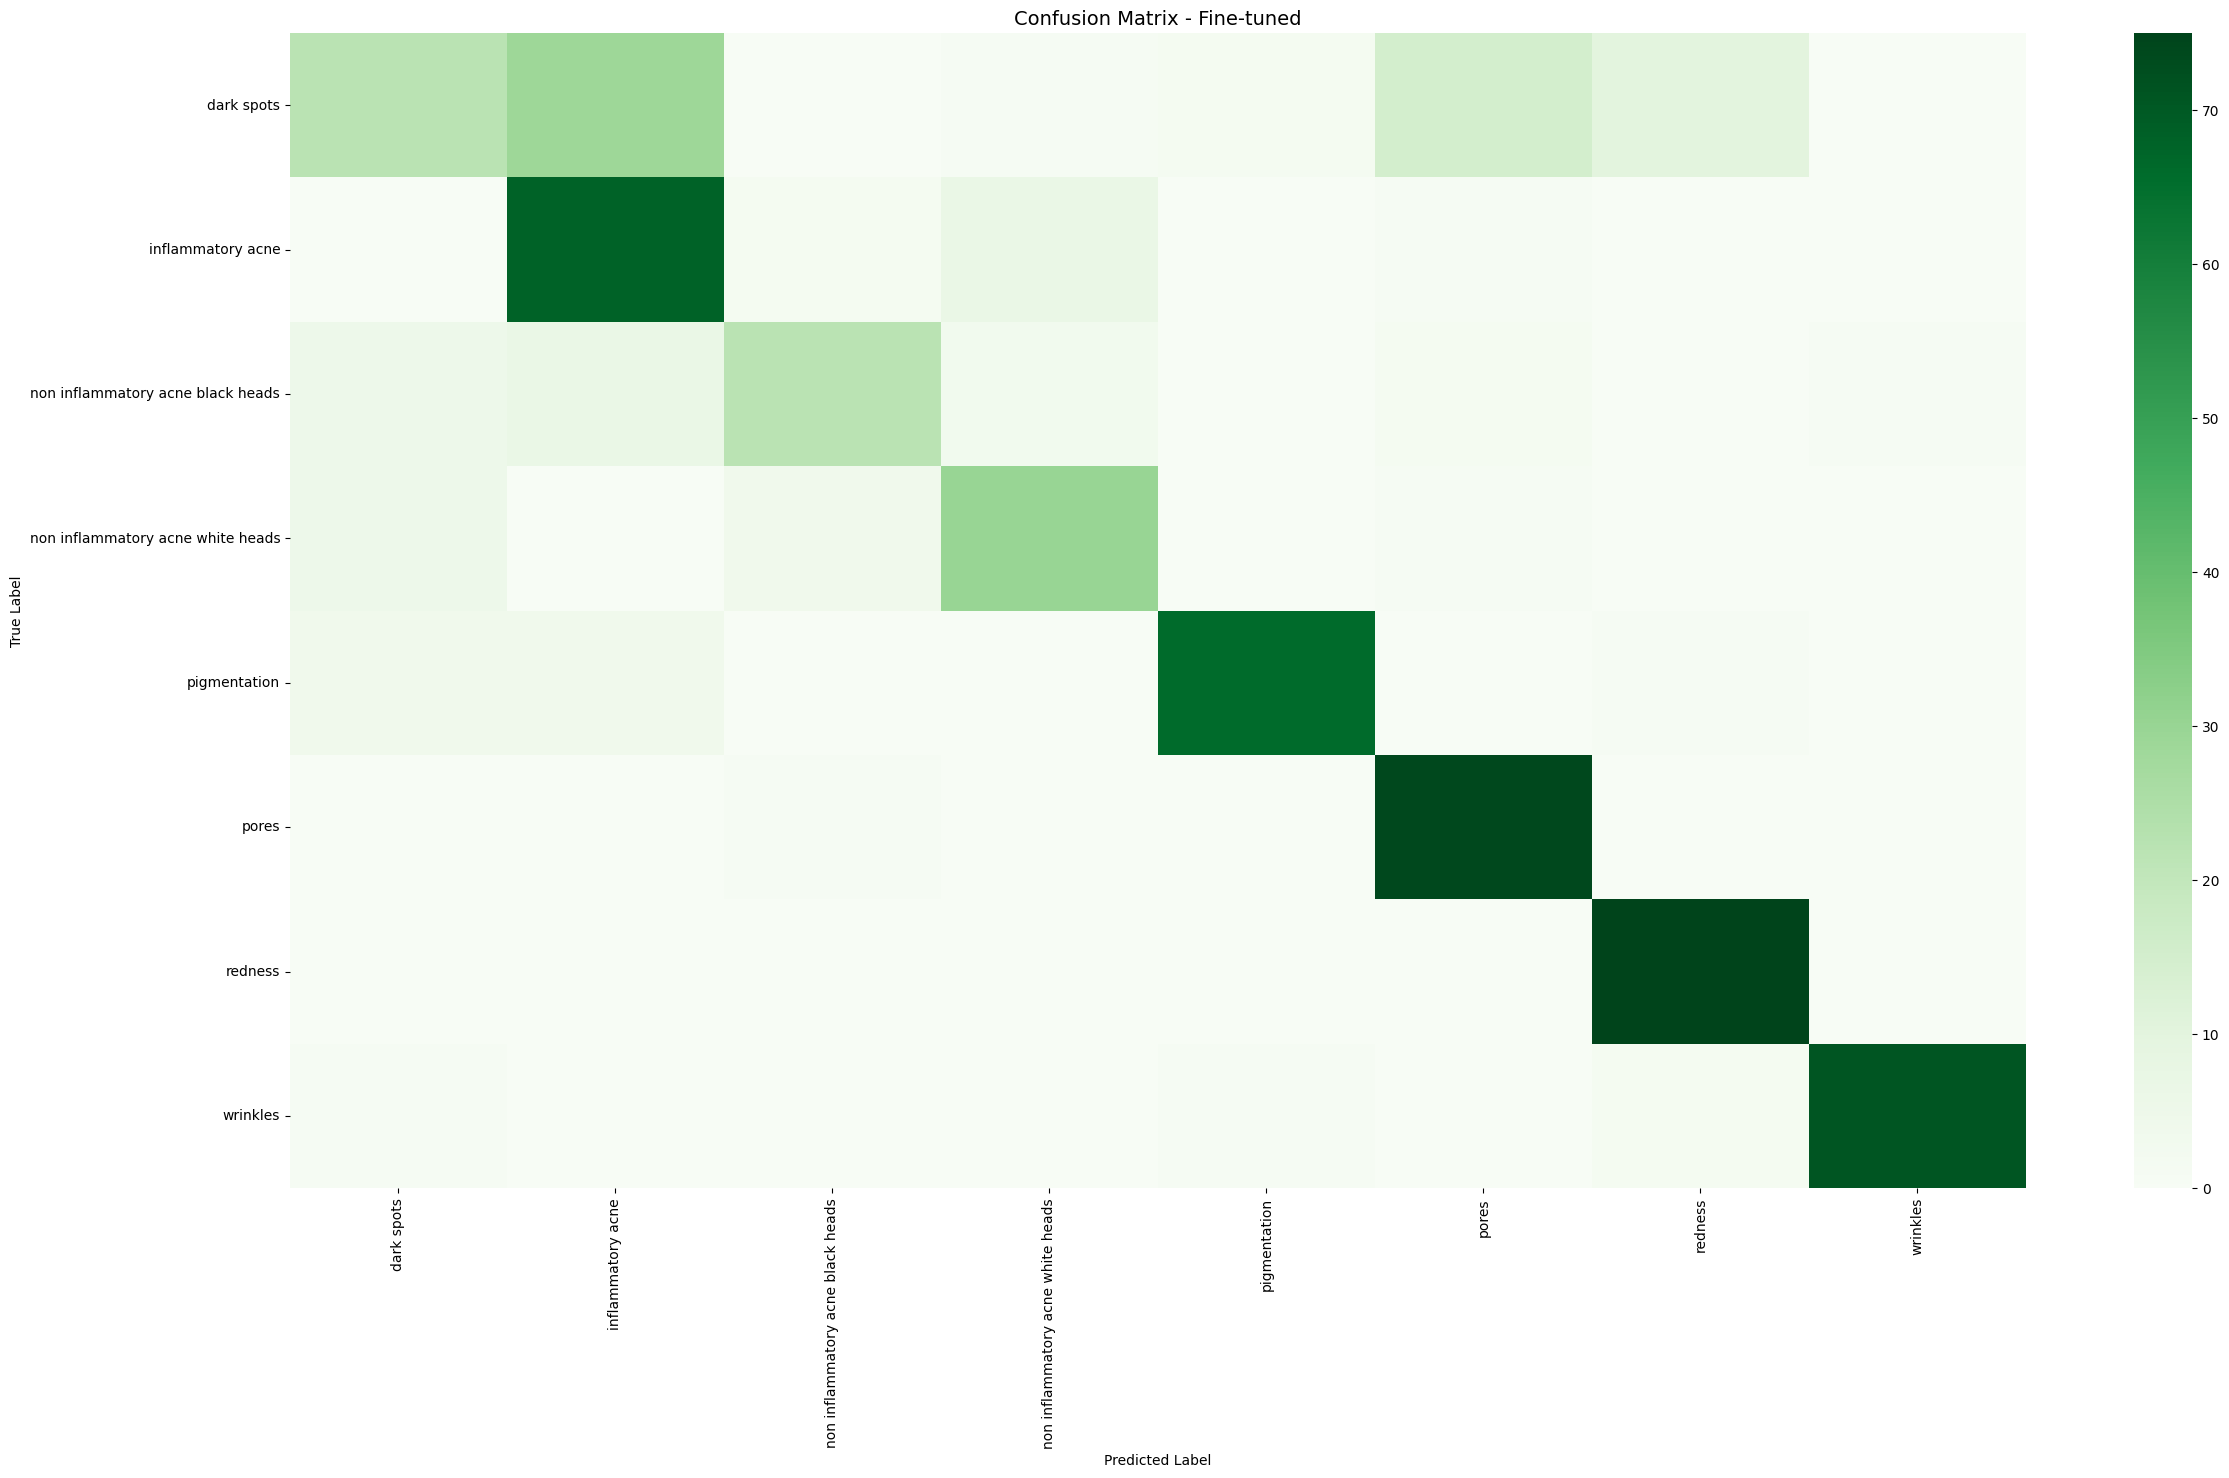

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.7970 - loss: 0.0899
Validation Loss : 0.090

Validation Accuracy : 0.797


In [13]:
# Classification Report
print('Classification Report\n')
print(classification_report(
    y_true_tuned, y_pred_tuned, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true_tuned, y_pred_tuned)

plt.figure(figsize=(28, 15))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fine-tuned', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Overall Metrics
val_loss_tuned, val_accuracy_tuned = model.evaluate(valid_ds, verbose=1)
print(f'Validation Loss : {val_loss_tuned:.3f}')
print(f'\nValidation Accuracy : {val_accuracy_tuned:.3f}')

In [ ]:
# <<<./ Load Best Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report

def categorical_focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/final-project/best_model.finetuned.keras',
    custom_objects={'loss_fn': categorical_focal_loss(gamma=2.0)})

In [ ]:
# <<<./ Collect Predictions
y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    y_true.append(np.argmax(labels.numpy(), axis=1))
    y_pred.append(np.argmax(predictions, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=['combination', 'dry', 'normal', 'oily']))

In [ ]:
test_ds

In [21]:
# <<<./ Evaluate on Test
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/final-project/attempt1A/best_model_concern.keras')

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.append(np.argmax(labels.numpy(), axis=1))
    y_pred.append(np.argmax(predictions, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=[
    'dark spots', 'inflammatory acne',
    'non inflammatory acne black heads', 'non inflammatory acne white heads',
    'pigmentation', 'pores', 'redness', 'wrinkles']))

                                   precision    recall  f1-score   support

                       dark spots       0.35      0.37      0.36        75
                inflammatory acne       0.63      0.92      0.75        75
non inflammatory acne black heads       0.92      0.63      0.75        38
non inflammatory acne white heads       0.94      0.91      0.93        35
                     pigmentation       0.85      0.23      0.36        74
                            pores       0.95      0.99      0.97        75
                          redness       0.72      0.93      0.81        75
                         wrinkles       0.95      0.97      0.96        75

                         accuracy                           0.74       522
                        macro avg       0.79      0.75      0.74       522
                     weighted avg       0.77      0.74      0.72       522

